# ECG Rhythm Classification with PhysioNet/CinC 2017

An electrocardiogram (ECG) records the heart's electrical activity over time. This notebook builds a reproducible **record-level rhythm classifier** using the PhysioNet/CinC Challenge 2017 dataset in `data/training2017`. Each recording has one reference label: normal rhythm (`N`), atrial fibrillation (`A`), other rhythm (`O`), or noisy recording (`~`). This is not the MIT-BIH Arrhythmia Database; it is the 2017 single-lead challenge dataset supplied in this workspace.

**Educational use only.** This project is not a medical device, does not provide a diagnosis, and must not guide clinical decisions. ECG interpretation requires qualified clinicians and appropriate external validation.

## 1. Environment and Imports

Install dependencies into the notebook's active Python environment if needed:

```bash
python -m pip install numpy pandas scipy matplotlib seaborn scikit-learn wfdb tensorflow
```

TensorFlow training can use a CPU, but training time depends on the machine. The random seeds below make data splits and model initialization reproducible; minor hardware-dependent training differences may remain.

In [1]:
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.signal as signal
import wfdb
import tensorflow as tf

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 4)

print("TensorFlow:", tf.__version__)
print("WFDB:", wfdb.__version__)

TensorFlow: 2.21.0
WFDB: 4.3.1


## 2. Load the Labeled Dataset

The supplied folder is `data/training2017`, which contains WFDB headers (`.hea`), MATLAB signal files (`.mat`), and the official two-column `REFERENCE.csv`. The reference file has no header: column 1 is the record name and column 2 is its rhythm label. We use `wfdb.rdrecord` to read signals and header metadata. The dataset labels are `N` (normal), `A` (atrial fibrillation), `O` (other rhythm), and `~` (noisy recording).

In [2]:
# Find the project root without relying on the notebook's launch directory.
project_root = next(
    (parent for parent in [Path.cwd(), *Path.cwd().parents]
     if (parent / "data" / "training2017").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        "Could not find data/training2017. Open this notebook from the project "
        "workspace, or update DATA_DIR to the dataset folder."
    )

DATA_DIR = project_root / "data" / "training2017"
REFERENCE_PATH = DATA_DIR / "REFERENCE.csv"
if not REFERENCE_PATH.exists():
    raise FileNotFoundError(
        f"Expected the labeled training reference file at {REFERENCE_PATH}. "
        "Do not substitute sample2017/answers.txt; that file contains sample "
        "algorithm predictions, not reference labels."
    )

records_df = pd.read_csv(
    REFERENCE_PATH, header=None, names=["record", "label"], dtype={"record": str, "label": str}
)
records_df["record"] = records_df["record"].str.strip()
records_df["label"] = records_df["label"].str.strip()

available_records = {path.stem for path in DATA_DIR.glob("*.hea")}
records_df = records_df[records_df["record"].isin(available_records)].reset_index(drop=True)
if records_df.empty:
    raise ValueError("No labeled records matched the WFDB headers in DATA_DIR.")

print(f"Dataset folder: {DATA_DIR.relative_to(project_root)}")
print(f"Labeled records with matching headers: {len(records_df):,}")
print("Labels found:", sorted(records_df["label"].unique()))
print(records_df.head())

# Inspect one real recording and the metadata parsed from its WFDB header.
example_id = records_df.loc[0, "record"]
example_record = wfdb.rdrecord(str(DATA_DIR / example_id), physical=True)
example_signal = np.asarray(example_record.p_signal[:, 0], dtype=np.float32)
example_fs = float(example_record.fs)
print(f"\nExample record: {example_id}")
print(f"Reference label: {records_df.loc[0, 'label']}")
print(f"Sampling frequency: {example_fs:g} Hz")
print(f"Signal shape: {example_signal.shape}; duration: {len(example_signal) / example_fs:.1f} s")
print(pd.Series(example_signal, name="ECG amplitude").describe().round(4))

Dataset folder: data\training2017
Labeled records with matching headers: 8,528
Labels found: ['A', 'N', 'O', '~']
   record label
0  A00001     N
1  A00002     N
2  A00003     N
3  A00004     A
4  A00005     A

Example record: A00001
Reference label: N
Sampling frequency: 300 Hz
Signal shape: (9000,); duration: 30.0 s
count    9000.0000
mean        0.0186
std         0.1683
min        -0.7540
25%        -0.0440
50%        -0.0030
75%         0.0420
max         0.9460
Name: ECG amplitude, dtype: float64


## 3. Exploratory Data Analysis

The target is one rhythm class per full recording. Class counts and the example signal's statistics help expose class imbalance, scale, and recording duration before training.

Labeled dataset shape: (8528, 2)

Class counts:


,records
label,
A,738
N,5050
O,2456
~,284


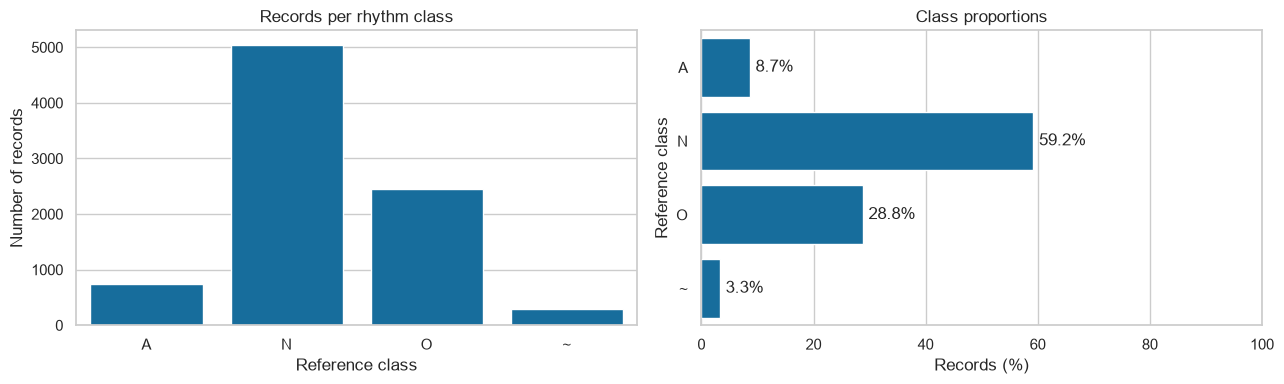

,A00001
samples,9000.0000
sampling_rate_hz,300.0000
duration_seconds,30.0000
mean,0.0186
standard_deviation,0.1683
minimum,-0.7540
maximum,0.9460


In [12]:
print("Labeled dataset shape:", records_df.shape)
print("\nClass counts:")
display(records_df["label"].value_counts().sort_index().rename("records").to_frame())

class_counts = records_df["label"].value_counts().sort_index()
class_proportions = class_counts / class_counts.sum() * 100
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0])
axes[0].set(title="Records per rhythm class", xlabel="Reference class", ylabel="Number of records")
sns.barplot(x=class_proportions.values, y=class_proportions.index, ax=axes[1])
axes[1].set(title="Class proportions", xlabel="Records (%)", ylabel="Reference class", xlim=(0, 100))
for bar in axes[1].patches:
    proportion = bar.get_width()
    axes[1].text(proportion + 1, bar.get_y() + bar.get_height() / 2, f"{proportion:.1f}%", va="center")
plt.tight_layout()
plt.show()

example_statistics = pd.Series({
    "samples": len(example_signal),
    "sampling_rate_hz": example_fs,
    "duration_seconds": len(example_signal) / example_fs,
    "mean": float(np.mean(example_signal)),
    "standard_deviation": float(np.std(example_signal)),
    "minimum": float(np.min(example_signal)),
    "maximum": float(np.max(example_signal)),
}, name=example_id)
display(example_statistics.to_frame().round(4))

## 4. Visualize ECGs by Class

The panels show the first 10 seconds of one real recording from each reference class. These are examples, not templates: rhythm morphology varies substantially between recordings and within a recording.

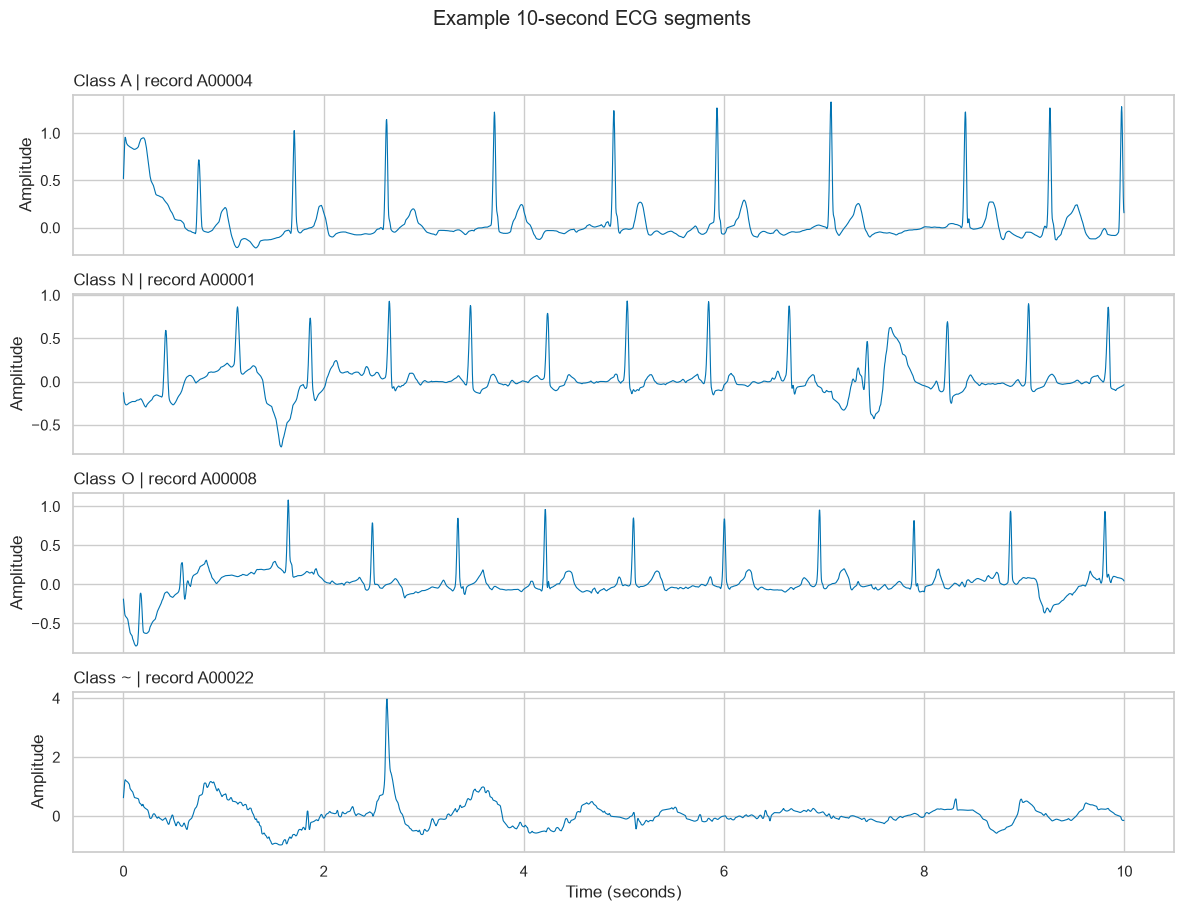

In [4]:
class_names = sorted(records_df["label"].unique())
fig, axes = plt.subplots(len(class_names), 1, figsize=(12, 9), sharex=True)
for ax, class_name in zip(axes, class_names):
    record_id = records_df.loc[records_df["label"] == class_name, "record"].iloc[0]
    record = wfdb.rdrecord(str(DATA_DIR / record_id), physical=True)
    trace = np.asarray(record.p_signal[:, 0], dtype=np.float32)
    sample_count = min(len(trace), int(10 * record.fs))
    time_seconds = np.arange(sample_count) / record.fs
    ax.plot(time_seconds, trace[:sample_count], linewidth=0.8)
    ax.set_title(f"Class {class_name} | record {record_id}", loc="left")
    ax.set_ylabel("Amplitude")
axes[-1].set_xlabel("Time (seconds)")
fig.suptitle("Example 10-second ECG segments", y=1.01)
plt.tight_layout()
plt.show()

Split **record IDs** first into training, validation, and held-out test sets. Patient identifiers are not supplied, so this is a record-level rather than patient-level split. Each complete signal is filtered at 0.5-40 Hz, resampled to 100 Hz, and normalized independently. We then create overlapping 10-second windows with a 5-second stride. Windows from the same ECG always remain in the same split; their probabilities are averaged to produce one rhythm prediction per record.

In [13]:
train_val_df, test_df = train_test_split(
    records_df,
    test_size=0.20,
    random_state=SEED,
    stratify=records_df["label"],
)
train_df, validation_df = train_test_split(
    train_val_df,
    test_size=0.15,
    random_state=SEED,
    stratify=train_val_df["label"],
)

TARGET_FS = 100
WINDOW_SECONDS = 10
WINDOW_SAMPLES = TARGET_FS * WINDOW_SECONDS
WINDOW_STEP_SECONDS = 5
WINDOW_STEP_SAMPLES = TARGET_FS * WINDOW_STEP_SECONDS
CLASS_NAMES = sorted(records_df["label"].unique())
CLASS_TO_INDEX = {name: index for index, name in enumerate(CLASS_NAMES)}

print(f"Training records:   {len(train_df):,}")
print(f"Validation records: {len(validation_df):,}")
print(f"Test records:       {len(test_df):,}")
print("Class order:", CLASS_NAMES)


def preprocess_record(record_id):
    """Filter and resample a full ECG, then return overlapping normalized windows."""
    record = wfdb.rdrecord(str(DATA_DIR / record_id), physical=True)
    sampling_rate = float(record.fs)
    trace = np.asarray(record.p_signal[:, 0], dtype=np.float32)

    upper_cutoff = min(40.0, sampling_rate * 0.45)
    if upper_cutoff <= 0.5:
        raise ValueError(f"Sampling rate too low for band-pass filtering: {sampling_rate} Hz")
    sos = signal.butter(
        3, [0.5, upper_cutoff], btype="bandpass", fs=sampling_rate, output="sos"
    )
    filtered = signal.sosfiltfilt(sos, trace)

    integer_fs = int(round(sampling_rate))
    if np.isclose(sampling_rate, integer_fs):
        divisor = np.gcd(integer_fs, TARGET_FS)
        resampled = signal.resample_poly(
            filtered, TARGET_FS // divisor, integer_fs // divisor
        )
    else:
        output_length = int(round(len(filtered) * TARGET_FS / sampling_rate))
        resampled = signal.resample(filtered, output_length)
    resampled = np.asarray(resampled, dtype=np.float32)

    resampled -= resampled.mean()
    scale = resampled.std()
    if scale > 1e-8:
        resampled /= scale

    if len(resampled) < WINDOW_SAMPLES:
        padding = WINDOW_SAMPLES - len(resampled)
        resampled = np.pad(resampled, (padding // 2, padding - padding // 2))

    final_start = len(resampled) - WINDOW_SAMPLES
    starts = list(range(0, final_start + 1, WINDOW_STEP_SAMPLES))
    if starts[-1] != final_start:
        starts.append(final_start)
    windows = [
        resampled[start:start + WINDOW_SAMPLES]
        for start in starts
    ]
    return np.asarray(windows, dtype=np.float32)


def transform_partition(partition_df):
    all_windows = []
    all_targets = []
    window_record_ids = []
    for record_id, label in partition_df[["record", "label"]].itertuples(index=False, name=None):
        windows = preprocess_record(record_id)
        all_windows.append(windows)
        all_targets.extend([CLASS_TO_INDEX[label]] * len(windows))
        window_record_ids.extend([record_id] * len(windows))
    return (
        np.concatenate(all_windows, axis=0),
        np.asarray(all_targets, dtype=np.int64),
        np.asarray(window_record_ids),
    )


def aggregate_record_probabilities(window_probabilities, window_record_ids, partition_df):
    """Average window probabilities to produce one prediction per ECG record."""
    probability_frame = pd.DataFrame(
        window_probabilities, columns=np.arange(len(CLASS_NAMES))
    )
    probability_frame["record"] = window_record_ids
    record_probabilities = probability_frame.groupby("record", sort=False).mean(numeric_only=True)
    record_probabilities = record_probabilities.reindex(partition_df["record"])
    record_labels = partition_df["label"].map(CLASS_TO_INDEX).to_numpy(dtype=np.int64)
    return record_probabilities.to_numpy(), record_labels


X_train, y_train, train_window_record_ids = transform_partition(train_df)
X_val, y_val_window, val_window_record_ids = transform_partition(validation_df)
X_test, y_test_window, test_window_record_ids = transform_partition(test_df)
y_val = validation_df["label"].map(CLASS_TO_INDEX).to_numpy(dtype=np.int64)
y_test = test_df["label"].map(CLASS_TO_INDEX).to_numpy(dtype=np.int64)

assert set(train_window_record_ids).isdisjoint(val_window_record_ids)
assert set(train_window_record_ids).isdisjoint(test_window_record_ids)
assert set(val_window_record_ids).isdisjoint(test_window_record_ids)

print("\nWindow-level feature shapes:")
print("Train:", X_train.shape, " Validation:", X_val.shape, " Test:", X_test.shape)
print("Windows per training record:")
display(pd.Series(train_window_record_ids).value_counts().describe().round(2).to_frame("windows"))
print("Records remain disjoint across train, validation, and test splits.")

Training records:   5,798
Validation records: 1,024
Test records:       1,706
Class order: ['A', 'N', 'O', '~']

Window-level feature shapes:
Train: (32604, 1000)  Validation: (5712, 1000)  Test: (9489, 1000)
Windows per training record:


,windows
count,5798.00
mean,5.62
std,2.16
min,1.00
25%,5.00
50%,5.00
75%,5.00
max,12.00


Records remain disjoint across train, validation, and test splits.


The baseline receives each normalized window as numeric features. Training samples are weighted so each record has equal total influence, with a configurable square-root class weighting (`CLASS_WEIGHT_STRENGTH`) to reduce majority-class bias without applying full inverse-frequency weights.

In [14]:
# 0.0 = no class balancing; 1.0 = full inverse-frequency balancing.
CLASS_WEIGHT_STRENGTH = 0.5
record_class_counts = train_df["label"].value_counts()
raw_class_weights = {
    CLASS_TO_INDEX[label]: (len(train_df) / (len(CLASS_NAMES) * count)) ** CLASS_WEIGHT_STRENGTH
    for label, count in record_class_counts.items()
}
weight_mean = np.average(
    list(raw_class_weights.values()),
    weights=[record_class_counts[label] for label in record_class_counts.index],
)
class_weights = {index: weight / weight_mean for index, weight in raw_class_weights.items()}

train_window_counts = pd.Series(train_window_record_ids).value_counts()
train_record_weights = np.asarray(
    [1.0 / train_window_counts[record_id] for record_id in train_window_record_ids],
    dtype=np.float32,
)
train_sample_weights = train_record_weights * np.asarray(
    [class_weights[class_index] for class_index in y_train], dtype=np.float32
)

random_forest = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    min_samples_leaf=2,
    class_weight=None,
    random_state=SEED,
    n_jobs=-1,
)
random_forest.fit(X_train, y_train, sample_weight=train_sample_weights)
rf_val_window_probabilities = random_forest.predict_proba(X_val)
rf_val_probabilities, y_val = aggregate_record_probabilities(
    rf_val_window_probabilities, val_window_record_ids, validation_df
)
rf_val_predictions = np.argmax(rf_val_probabilities, axis=1)
print("Random Forest validation record-level accuracy:", round(accuracy_score(y_val, rf_val_predictions), 4))
print("Random Forest validation record-level macro F1:", round(f1_score(y_val, rf_val_predictions, average="macro"), 4))
print("Mild class weights:", {CLASS_NAMES[index]: round(weight, 3) for index, weight in class_weights.items()})

Random Forest validation record-level accuracy: 0.5918
Random Forest validation record-level macro F1: 0.1875
Mild class weights: {'N': np.float64(0.729), 'O': np.float64(1.045), 'A': np.float64(1.908), '~': np.float64(3.075)}


## 7. 1D Convolutional Neural Network

A 1D CNN learns local waveform patterns directly from the sampled signal. The network is deliberately small. It uses class-weighted loss and early stopping on the validation set; the held-out test records remain untouched until the final comparison.

In [16]:
X_train_cnn = X_train[..., np.newaxis]
X_val_cnn = X_val[..., np.newaxis]

val_window_counts = pd.Series(val_window_record_ids).value_counts()
val_window_weights = np.asarray(
    [1.0 / val_window_counts[record_id] for record_id in val_window_record_ids],
    dtype=np.float32,
)


def augment_training_window(ecg_window, label, sample_weight):
    shift = tf.random.uniform([], minval=-25, maxval=26, dtype=tf.int32)
    shifted = tf.roll(ecg_window, shift=shift, axis=0)
    gain = tf.random.uniform([], minval=0.9, maxval=1.1)
    noise = tf.random.normal(tf.shape(shifted), stddev=0.015)
    return shifted * gain + noise, label, sample_weight


train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train_cnn, y_train, train_sample_weights))
    .shuffle(min(len(y_train), 8192), seed=SEED, reshuffle_each_iteration=True)
    .map(augment_training_window, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
    .prefetch(tf.data.AUTOTUNE)
)

cnn_model = keras.Sequential([
    keras.Input(shape=(WINDOW_SAMPLES, 1)),
    layers.Conv1D(16, kernel_size=7, padding="same", activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(32, kernel_size=5, padding="same", activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(64, kernel_size=3, padding="same", activation="relu"),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.35),
    layers.Dense(len(CLASS_NAMES), activation="softmax"),
])
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=6, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5
    ),
]

history = cnn_model.fit(
    train_dataset,
    validation_data=(X_val_cnn, y_val_window, val_window_weights),
    epochs=40,
    shuffle=False,
    callbacks=callbacks,
    verbose=2,
)

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
print(f"Best validation-loss epoch: {best_epoch}")
print("Training-only augmentation: +/-0.25-second circular shift, gain 0.9-1.1, Gaussian noise std=0.015")

Epoch 1/40
510/510 - 12s - 23ms/step - accuracy: 0.5644 - loss: 0.2137 - val_accuracy: 0.5748 - val_loss: 0.1826 - learning_rate: 0.0010
Epoch 2/40
510/510 - 10s - 20ms/step - accuracy: 0.5711 - loss: 0.1946 - val_accuracy: 0.6211 - val_loss: 0.1677 - learning_rate: 0.0010
Epoch 3/40
510/510 - 10s - 20ms/step - accuracy: 0.5945 - loss: 0.1879 - val_accuracy: 0.6341 - val_loss: 0.1652 - learning_rate: 0.0010
Epoch 4/40
510/510 - 11s - 21ms/step - accuracy: 0.6110 - loss: 0.1797 - val_accuracy: 0.6399 - val_loss: 0.1540 - learning_rate: 0.0010
Epoch 5/40
510/510 - 11s - 21ms/step - accuracy: 0.6239 - loss: 0.1730 - val_accuracy: 0.6392 - val_loss: 0.1486 - learning_rate: 0.0010
Epoch 6/40
510/510 - 10s - 20ms/step - accuracy: 0.6327 - loss: 0.1662 - val_accuracy: 0.6406 - val_loss: 0.1515 - learning_rate: 0.0010
Epoch 7/40
510/510 - 9s - 18ms/step - accuracy: 0.6376 - loss: 0.1638 - val_accuracy: 0.6444 - val_loss: 0.1430 - learning_rate: 0.0010
Epoch 8/40
510/510 - 10s - 21ms/step - acc

Both models are evaluated at the **record level**: overlapping-window probabilities are averaged within each recording. We report default argmax and validation-tuned class multipliers; the multipliers are selected using validation macro-F1 only. The held-out test set is not used for model or threshold selection. Accuracy is accompanied by macro precision, recall, and F1, plus macro one-vs-rest ROC-AUC.

Random Forest validation-tuned multipliers: {'A': np.float32(1.6), 'N': np.float32(0.6), 'O': np.float32(0.8), '~': np.float32(0.6)}; validation macro F1=0.299
1D CNN validation-tuned multipliers: {'A': np.float32(1.25), 'N': np.float32(0.8), 'O': np.float32(1.0), '~': np.float32(0.6)}; validation macro F1=0.617


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,roc_auc_ovr_macro
model_and_decision,,,,,,
Random Forest (argmax),0.5938,0.3359,0.2515,0.1892,0.4445,0.7100
Random Forest (validation-tuned),0.6131,0.3477,0.3022,0.2924,0.5436,0.7100
1D CNN (argmax),0.6835,0.5739,0.6231,0.5765,0.6644,0.8439
1D CNN (validation-tuned),0.6993,0.6058,0.6512,0.6204,0.6875,0.8439



Random Forest (argmax) classification report
              precision    recall  f1-score   support

           A      0.000     0.000     0.000       148
           N      0.593     1.000     0.745      1010
           O      0.750     0.006     0.012       491
           ~      0.000     0.000     0.000        57

    accuracy                          0.594      1706
   macro avg      0.336     0.252     0.189      1706
weighted avg      0.567     0.594     0.444      1706


Random Forest (validation-tuned) classification report
              precision    recall  f1-score   support

           A      0.268     0.074     0.116       148
           N      0.643     0.921     0.757      1010
           O      0.479     0.214     0.296       491
           ~      0.000     0.000     0.000        57

    accuracy                          0.613      1706
   macro avg      0.348     0.302     0.292      1706
weighted avg      0.542     0.613     0.544      1706


1D CNN (argmax) classificat

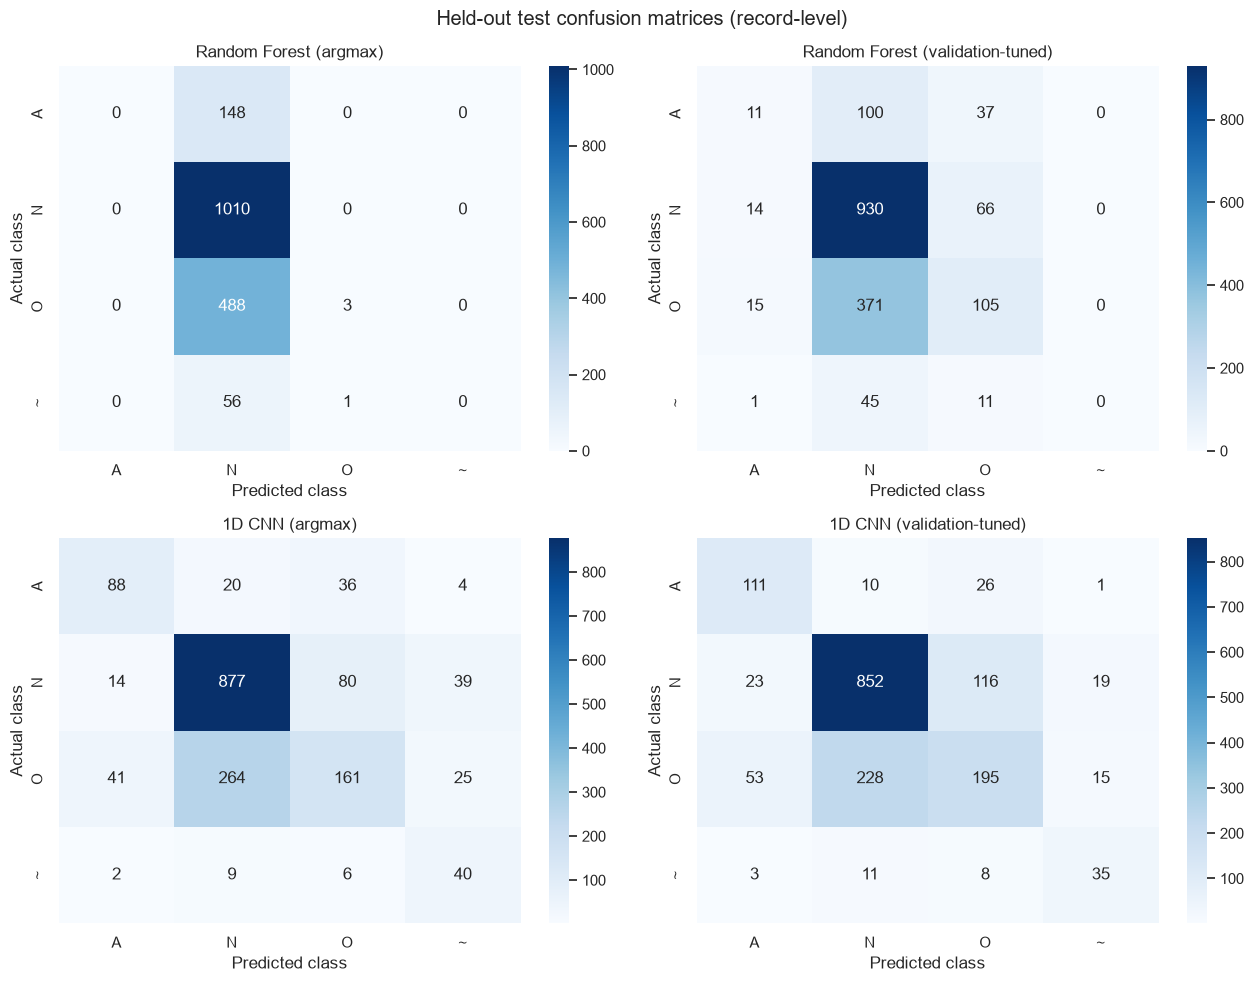

In [17]:
from itertools import product

cnn_val_window_probabilities = cnn_model.predict(X_val_cnn, verbose=0)
cnn_val_probabilities, y_val = aggregate_record_probabilities(
    cnn_val_window_probabilities, val_window_record_ids, validation_df
)
cnn_test_window_probabilities = cnn_model.predict(X_test[..., np.newaxis], verbose=0)
cnn_test_probabilities, y_test = aggregate_record_probabilities(
    cnn_test_window_probabilities, test_window_record_ids, test_df
)

rf_test_window_probabilities = random_forest.predict_proba(X_test)
rf_test_probabilities, y_test = aggregate_record_probabilities(
    rf_test_window_probabilities, test_window_record_ids, test_df
)


def tune_class_multipliers(validation_probabilities, validation_targets):
    """Select class-wise probability multipliers using validation macro-F1 only."""
    candidates = (0.6, 0.8, 1.0, 1.25, 1.6)
    best_multipliers = np.ones(len(CLASS_NAMES), dtype=np.float32)
    best_score = (-1.0, -1.0)
    for candidate_tuple in product(candidates, repeat=len(CLASS_NAMES)):
        candidate_multipliers = np.asarray(candidate_tuple, dtype=np.float32)
        candidate_predictions = np.argmax(
            validation_probabilities * candidate_multipliers, axis=1
        )
        score = (
            f1_score(validation_targets, candidate_predictions, average="macro"),
            accuracy_score(validation_targets, candidate_predictions),
        )
        if score > best_score:
            best_score = score
            best_multipliers = candidate_multipliers
    return best_multipliers, best_score


model_probabilities = {
    "Random Forest": (rf_val_probabilities, rf_test_probabilities),
    "1D CNN": (cnn_val_probabilities, cnn_test_probabilities),
}
tuned_multipliers = {}
evaluation_predictions = {}
predictions = {}
probabilities = {}

for model_name, (validation_probabilities, test_probabilities) in model_probabilities.items():
    multipliers, validation_score = tune_class_multipliers(validation_probabilities, y_val)
    tuned_multipliers[model_name] = multipliers
    default_predictions = np.argmax(test_probabilities, axis=1)
    tuned_predictions = np.argmax(test_probabilities * multipliers, axis=1)
    evaluation_predictions[f"{model_name} (argmax)"] = default_predictions
    evaluation_predictions[f"{model_name} (validation-tuned)"] = tuned_predictions
    predictions[model_name] = tuned_predictions
    probabilities[model_name] = test_probabilities
    print(
        f"{model_name} validation-tuned multipliers: "
        f"{dict(zip(CLASS_NAMES, multipliers.round(2)))}; "
        f"validation macro F1={validation_score[0]:.3f}"
    )

comparison_rows = []
for evaluation_name, y_pred in evaluation_predictions.items():
    model_name = evaluation_name.split(" (")[0]
    try:
        auc = roc_auc_score(
            label_binarize(y_test, classes=np.arange(len(CLASS_NAMES))),
            probabilities[model_name],
            average="macro",
        )
    except ValueError as error:
        warnings.warn(f"ROC-AUC unavailable for {model_name}: {error}")
        auc = np.nan

    comparison_rows.append({
        "model_and_decision": evaluation_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr_macro": auc,
    })

results_df = pd.DataFrame(comparison_rows).set_index("model_and_decision")
display(results_df.round(4))

for evaluation_name, y_pred in evaluation_predictions.items():
    print(f"\n{evaluation_name} classification report")
    print(classification_report(
        y_test,
        y_pred,
        labels=np.arange(len(CLASS_NAMES)),
        target_names=CLASS_NAMES,
        zero_division=0,
        digits=3,
    ))

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (evaluation_name, y_pred) in zip(axes.flat, evaluation_predictions.items()):
    matrix = confusion_matrix(y_test, y_pred, labels=np.arange(len(CLASS_NAMES)))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax,
    )
    ax.set(title=evaluation_name, xlabel="Predicted class", ylabel="Actual class")
fig.suptitle("Held-out test confusion matrices (record-level)")
plt.tight_layout()
plt.show()

## 9. Training Curves and Fit Diagnostics

The CNN's training and validation curves help distinguish overfitting (training improves while validation degrades) from underfitting or a difficult task (both remain weak). The diagnostic below is a heuristic, not a clinical or statistical guarantee.

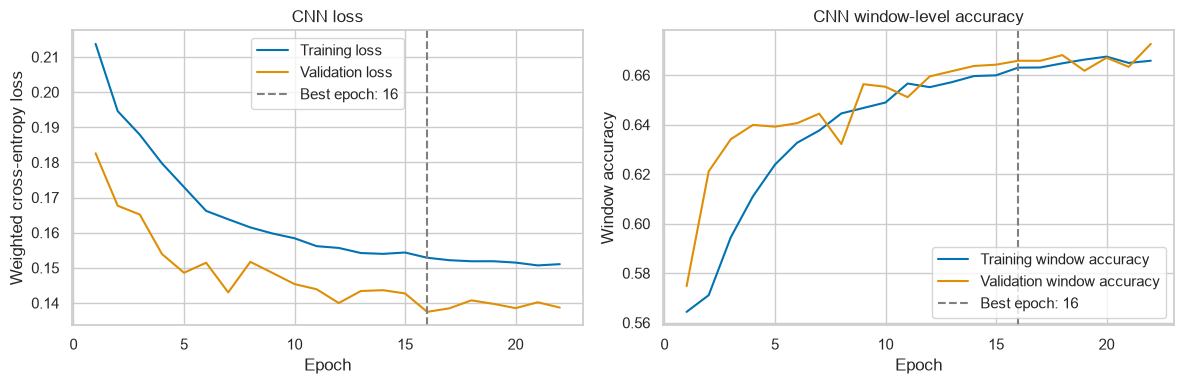

At epoch 16: train/validation window accuracy=0.663/0.666; train/validation loss=0.153/0.137
Window-level accuracies remain modest, but there is no clear overfitting signal. Use the record-level test report for final generalization assessment.


In [18]:
epochs_ran = np.arange(1, len(history.history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_ran, history.history["loss"], label="Training loss")
axes[0].plot(epochs_ran, history.history["val_loss"], label="Validation loss")
axes[0].axvline(best_epoch, color="gray", linestyle="--", label=f"Best epoch: {best_epoch}")
axes[0].set(title="CNN loss", xlabel="Epoch", ylabel="Weighted cross-entropy loss")
axes[0].legend()
axes[1].plot(epochs_ran, history.history["accuracy"], label="Training window accuracy")
axes[1].plot(epochs_ran, history.history["val_accuracy"], label="Validation window accuracy")
axes[1].axvline(best_epoch, color="gray", linestyle="--", label=f"Best epoch: {best_epoch}")
axes[1].set(title="CNN window-level accuracy", xlabel="Epoch", ylabel="Window accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

train_accuracy_at_best = history.history["accuracy"][best_epoch - 1]
val_accuracy_at_best = history.history["val_accuracy"][best_epoch - 1]
train_loss_at_best = history.history["loss"][best_epoch - 1]
val_loss_at_best = history.history["val_loss"][best_epoch - 1]
if val_loss_at_best > train_loss_at_best * 1.25:
    fit_diagnosis = "Possible overfitting: best-epoch validation loss is notably above training loss."
elif max(train_accuracy_at_best, val_accuracy_at_best) < 0.70:
    fit_diagnosis = (
        "Window-level accuracies remain modest, but there is no clear overfitting signal. "
        "Use the record-level test report for final generalization assessment."
    )
else:
    fit_diagnosis = "No clear overfitting signal at the best validation-loss epoch."
print(
    f"At epoch {best_epoch}: train/validation window accuracy="
    f"{train_accuracy_at_best:.3f}/{val_accuracy_at_best:.3f}; "
    f"train/validation loss={train_loss_at_best:.3f}/{val_loss_at_best:.3f}"
)
print(fit_diagnosis)

## 10. Predict an Unseen Test Recording

This example is selected from the held-out test partition. Its true label was not used during either model's training or validation. The plot shows the same filtered, normalized 10-second window used for inference.

Held-out record: A07929
Actual class: N
Random Forest validation-tuned prediction: N
1D CNN validation-tuned prediction: N
Windows averaged for record-level prediction: 5


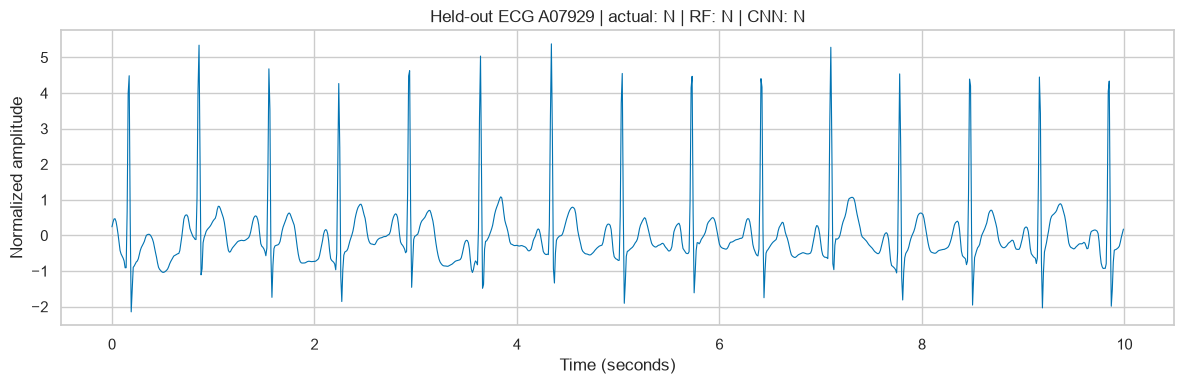

In [19]:
prediction_index = 0
unseen_record_id = test_df.iloc[prediction_index]["record"]
actual_label = CLASS_NAMES[y_test[prediction_index]]
rf_label = CLASS_NAMES[predictions["Random Forest"][prediction_index]]
cnn_label = CLASS_NAMES[predictions["1D CNN"][prediction_index]]
record_window_indices = np.flatnonzero(test_window_record_ids == unseen_record_id)
selected_window_index = record_window_indices[len(record_window_indices) // 2]
unseen_signal = X_test[selected_window_index]

print("Held-out record:", unseen_record_id)
print("Actual class:", actual_label)
print("Random Forest validation-tuned prediction:", rf_label)
print("1D CNN validation-tuned prediction:", cnn_label)
print("Windows averaged for record-level prediction:", len(record_window_indices))

seconds = np.arange(WINDOW_SAMPLES) / TARGET_FS
plt.figure(figsize=(12, 4))
plt.plot(seconds, unseen_signal, linewidth=0.8)
plt.title(
    f"Held-out ECG {unseen_record_id} | actual: {actual_label} | "
    f"RF: {rf_label} | CNN: {cnn_label}"
)
plt.xlabel("Time (seconds)")
plt.ylabel("Normalized amplitude")
plt.tight_layout()
plt.show()

## 11. Conclusion

The summary below is generated from the held-out metrics above, so it updates automatically when you rerun the notebook with a different split or configuration.

In [20]:
best_f1_name = results_df["f1_macro"].idxmax()
best_f1_metrics = results_df.loc[best_f1_name]
best_accuracy_name = results_df["accuracy"].idxmax()
best_accuracy_metrics = results_df.loc[best_accuracy_name]

print(f"Best model/decision by held-out macro F1: {best_f1_name}")
print(f"Accuracy: {best_f1_metrics['accuracy']:.3f}")
print(f"Macro precision / recall / F1: {best_f1_metrics['precision_macro']:.3f} / "
      f"{best_f1_metrics['recall_macro']:.3f} / {best_f1_metrics['f1_macro']:.3f}")
print(f"Macro one-vs-rest ROC-AUC: {best_f1_metrics['roc_auc_ovr_macro']:.3f}")
print(f"Highest held-out accuracy: {best_accuracy_metrics['accuracy']:.3f} ({best_accuracy_name})")
print(f"90% accuracy target met in this run: {best_accuracy_metrics['accuracy'] >= 0.90}")
print("CNN fit diagnostic:", fit_diagnosis)

Best model/decision by held-out macro F1: 1D CNN (validation-tuned)
Accuracy: 0.699
Macro precision / recall / F1: 0.606 / 0.651 / 0.620
Macro one-vs-rest ROC-AUC: 0.844
Highest held-out accuracy: 0.699 (1D CNN (validation-tuned))
90% accuracy target met in this run: False
CNN fit diagnostic: Window-level accuracies remain modest, but there is no clear overfitting signal. Use the record-level test report for final generalization assessment.


### Interpretation and Next Steps

Use the held-out comparison and generated summary above as the measured result for this run. The validation-tuned decision rule optimizes macro-F1, so accuracy may not be the largest possible; compare class-wise recall and the confusion matrices before changing that objective. The current run does not establish 90%+ accuracy, and no target should be promised without repeatable evaluation.

**Limitations:** this is a single-lead educational experiment on one train/test partition. Records are split independently because patient IDs are unavailable, so patient-level generalization is not measured. Class imbalance remains substantial, and the other-rhythm class is heterogeneous. There is no external cohort or clinical validation; these results must not be interpreted as diagnostic performance.

**Further experiments:** compare longer and overlapping windows, alternative probability aggregation (mean, median, or learned record-level pooling), and larger residual or dilated CNNs. Tune filter settings, augmentation strength, and class-weight strength using record-level validation or cross-validation only. Consider focal loss or calibrated probabilities, inspect errors by class and record duration, and add an external patient-separated test set when possible. Keep the existing test split untouched while selecting changes.